# 05 - Tiny DDPM From Scratch on MNIST
Minimal implementation of DDPM.

## Setup

In [ ]:
!pip -q install torch torchvision matplotlib

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print("device:", DEVICE)

device: cuda


## Step 1: The Noise Schedule

In [ ]:
T = 1000
betas = torch.linspace(1e-4, 0.02, T, device=DEVICE)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def q_sample(x0, t, noise):
    a_bar = alpha_bars[t].reshape(-1, 1, 1, 1)
    return a_bar.sqrt() * x0 + (1 - a_bar).sqrt() * noise


## Step 2: A Tiny U-Net

In [ ]:
class TimeEmbed(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(nn.Linear(dim, dim*4), nn.GELU(), nn.Linear(dim*4, dim*4))

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t.float()[:, None] * freqs[None]
        emb = torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)
        return self.mlp(emb)                                # (B, dim*4)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.proj = nn.Linear(time_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = F.silu(self.conv1(x)) + self.proj(t_emb)[:, :, None, None]
        h = F.silu(self.conv2(h))
        return h + self.skip(x)

class TinyUNet(nn.Module):
    def __init__(self, in_ch=1, base=32, time_dim_in=64):
        super().__init__()
        self.t_embed = TimeEmbed(time_dim_in)
        t_dim = time_dim_in * 4
        self.down1 = ResBlock(in_ch, base, t_dim)
        self.down2 = ResBlock(base, base*2, t_dim)
        self.mid   = ResBlock(base*2, base*2, t_dim)
        self.up1   = ResBlock(base*2 + base, base, t_dim) # Corrected: base*2 + base (64 + 32 = 96 channels)
        self.up2   = ResBlock(base + in_ch, base, t_dim)
        self.head  = nn.Conv2d(base, in_ch, 1)

    def forward(self, x, t):
        te = self.t_embed(t)
        d1 = self.down1(x, te)                              # 28
        d2 = self.down2(F.avg_pool2d(d1, 2), te)            # 14
        m  = self.mid(d2, te)                               # 14
        u1 = self.up1(torch.cat([F.interpolate(m, scale_factor=2), d1], dim=1), te)  # 28
        u2 = self.up2(torch.cat([u1, x], dim=1), te)         # 28
        return self.head(u2)

## Step 3: Train

In [ ]:
tfm = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x*2 - 1)])
ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
# Use the full dataset for better learning
loader = DataLoader(ds, batch_size=128, shuffle=True, num_workers=2)

# Increase base channels to 64 for higher model capacity
model = TinyUNet(base=64).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=2e-4)

EPOCHS = 20 # Train for more epochs on the full dataset

for epoch in range(EPOCHS):
    for step, (x0, _) in enumerate(loader):
        x0 = x0.to(DEVICE)
        B = x0.size(0)
        t = torch.randint(0, T, (B,), device=DEVICE)
        noise = torch.randn_like(x0)
        xt = q_sample(x0, t, noise)
        pred = model(xt, t)
        loss = F.mse_loss(pred, noise)
        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 200 == 0:
            print(f"epoch {epoch+1}  step {step:4d}  loss {loss.item():.4f}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 65.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]


epoch 1  step    0  loss 1.0723
epoch 1  step  200  loss 0.0566
epoch 1  step  400  loss 0.0439
epoch 2  step    0  loss 0.0397
epoch 2  step  200  loss 0.0539
epoch 2  step  400  loss 0.0472
epoch 3  step    0  loss 0.0344
epoch 3  step  200  loss 0.0269
epoch 3  step  400  loss 0.0332
epoch 4  step    0  loss 0.0302
epoch 4  step  200  loss 0.0311
epoch 4  step  400  loss 0.0366
epoch 5  step    0  loss 0.0241
epoch 5  step  200  loss 0.0261
epoch 5  step  400  loss 0.0438
epoch 6  step    0  loss 0.0353
epoch 6  step  200  loss 0.0265
epoch 6  step  400  loss 0.0273
epoch 7  step    0  loss 0.0300
epoch 7  step  200  loss 0.0290
epoch 7  step  400  loss 0.0351
epoch 8  step    0  loss 0.0297
epoch 8  step  200  loss 0.0299
epoch 8  step  400  loss 0.0271
epoch 9  step    0  loss 0.0227
epoch 9  step  200  loss 0.0286
epoch 9  step  400  loss 0.0277
epoch 10  step    0  loss 0.0277
epoch 10  step  200  loss 0.0303
epoch 10  step  400  loss 0.0280
epoch 11  step    0  loss 0.0198
epoc

## Step 4: Sample

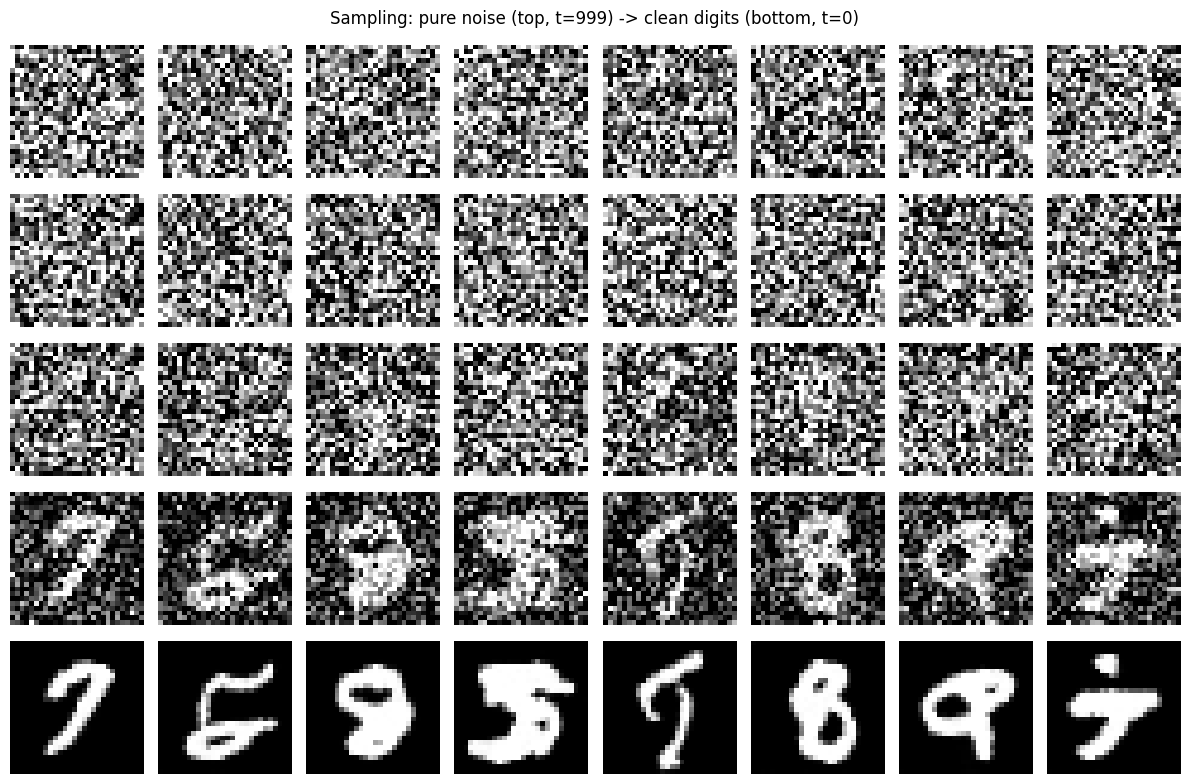

In [ ]:
@torch.no_grad()
def sample(n=16, snapshots=None):
    snapshots = snapshots or []
    x = torch.randn(n, 1, 28, 28, device=DEVICE)
    history = {}
    for t in reversed(range(T)):
        tt = torch.full((n,), t, device=DEVICE, dtype=torch.long)
        pred_noise = model(x, tt)
        alpha = alphas[t]
        alpha_bar = alpha_bars[t]
        beta = betas[t]
        mean = (1 / alpha.sqrt()) * (x - (beta / (1 - alpha_bar).sqrt()) * pred_noise)
        if t > 0:
            noise = torch.randn_like(x)
            sigma = beta.sqrt()
            x = mean + sigma * noise
        else:
            x = mean
        if t in snapshots:
            history[t] = x.clamp(-1, 1).cpu()
    return x.clamp(-1, 1).cpu(), history

samples, snaps = sample(n=8, snapshots=[999, 750, 500, 250, 0])

fig, axs = plt.subplots(5, 8, figsize=(12, 8))
for row, t in enumerate(sorted(snaps.keys(), reverse=True)):
    for col in range(8):
        axs[row, col].imshow((snaps[t][col, 0] + 1) / 2, cmap="gray")
        axs[row, col].axis("off")
    axs[row, 0].set_ylabel(f"t={t}", rotation=0, labelpad=30)
fig.suptitle("Sampling: pure noise (top, t=999) -> clean digits (bottom, t=0)")
plt.tight_layout()
plt.show()


## Takeaways
End of minimal diffusion pipeline.